In [57]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
train = pd.read_csv("data/train_movie.csv")
test = pd.read_csv("data/test_movie.csv")

In [59]:
train.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [60]:
train.shape, test.shape

((3000, 23), (4398, 22))

In [61]:
for i, e in enumerate(train['belongs_to_collection']):
    print(i, e)

0 [{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]
1 [{'id': 107674, 'name': 'The Princess Diaries Collection', 'poster_path': '/wt5AMbxPTS4Kfjx7Fgm149qPfZl.jpg', 'backdrop_path': '/zSEtYD77pKRJlUPx34BJgUG9v1c.jpg'}]
2 nan
3 nan
4 nan
5 nan
6 nan
7 nan
8 [{'id': 256377, 'name': 'The Muppet Collection', 'poster_path': '/8Ew8EIdFFurMMYjSbWPu1Hl4vLX.jpg', 'backdrop_path': '/1AWd3MM90G47mxtD112gRDxSXY9.jpg'}]
9 nan
10 [{'id': 1575, 'name': 'Rocky Collection', 'poster_path': '/mCY5dMkSSFQufGCViI6jNUU6pXq.jpg', 'backdrop_path': '/w4h6gjdWPvmu5R9H6zeGDPo1ZuV.jpg'}]
11 [{'id': 48190, 'name': 'Revenge of the Nerds Collection', 'poster_path': '/qOnoXEdrSnBuS3FMAFRIgyJSM2r.jpg', 'backdrop_path': None}]
12 nan
13 [{'id': 91698, 'name': 'Chili Palmer Collection', 'poster_path': '/ae3smJDdWrMJ77tDpYOrpo4frKq.jpg', 'backdrop_path': '/uWaANGQeoSs5vSP1CWtlkDrkqei.jpg'}]
14 nan
15 nan
16 na

In [62]:
print(train['belongs_to_collection'].apply(lambda x: len(x) if pd.notna(x) else 0).value_counts())

belongs_to_collection
0      2396
153      53
149      45
151      38
152      38
       ... 
102       1
135       1
126       1
118       1
90        1
Name: count, Length: 64, dtype: int64


In [63]:
train['belongs_to_collection'].head()

0    [{'id': 313576, 'name': 'Hot Tub Time Machine ...
1    [{'id': 107674, 'name': 'The Princess Diaries ...
2                                                  NaN
3                                                  NaN
4                                                  NaN
Name: belongs_to_collection, dtype: str

In [64]:
train['belongs_to_collection'].info()

<class 'pandas.Series'>
RangeIndex: 3000 entries, 0 to 2999
Series name: belongs_to_collection
Non-Null Count  Dtype
--------------  -----
604 non-null    str  
dtypes: str(1)
memory usage: 23.6 KB


In [65]:
from functools import wraps

def handle_na(default=None):
    def decorator(func):
        @wraps(func)
        def wrapper(x, *args, **kwargs):
            if pd.notna(x):
                return func(x, *args, **kwargs)
            return default

        return wrapper

    return decorator

In [66]:
@handle_na(default=0)
def retrieve_name(x):
    x = ast.literal_eval(x)
    return x[0]['name']

In [67]:
@handle_na(default=0)
def has_collection(x):
    return len(x)

In [68]:
train['collection_name'] = train['belongs_to_collection'].apply(lambda x: retrieve_name(x))

In [69]:
train['collection_name'].head()

0    Hot Tub Time Machine Collection
1    The Princess Diaries Collection
2                                  0
3                                  0
4                                  0
Name: collection_name, dtype: object

In [70]:
train['has_collection'] = train['belongs_to_collection'].apply(lambda x: has_collection(x))

In [71]:
train['has_collection'].head()

0    163
1    163
2      0
3      0
4      0
Name: has_collection, dtype: int64

In [72]:
test['collection_name'] = test['belongs_to_collection'].apply(lambda x: retrieve_name(x))
test['has_collection'] = test['belongs_to_collection'].apply(lambda x: has_collection(x))

In [73]:
train[['collection_name', 'has_collection']].head()

,collection_name,has_collection
0,Hot Tub Time Machine Collection,163
1,The Princess Diaries Collection,163
2,0,0
3,0,0
4,0,0


In [74]:
train.drop(columns=['belongs_to_collection'], inplace=True)
test.drop(columns=['belongs_to_collection'], inplace=True)

In [75]:
train.head()

,id,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,collection_name,has_collection
0,1,14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651,Hot Tub Time Machine Collection,163
1,2,40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435,The Princess Diaries Collection,163
2,3,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000,0,0
3,4,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000,0,0
4,5,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970,0,0


In [76]:
for i, e in enumerate(train['genres'][:5]):
    print(i, e)

0 [{'id': 35, 'name': 'Comedy'}]
1 [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10751, 'name': 'Family'}, {'id': 10749, 'name': 'Romance'}]
2 [{'id': 18, 'name': 'Drama'}]
3 [{'id': 53, 'name': 'Thriller'}, {'id': 18, 'name': 'Drama'}]
4 [{'id': 28, 'name': 'Action'}, {'id': 53, 'name': 'Thriller'}]


In [77]:
train['genres'].apply(lambda x: len(x) if pd.notna(x) else 0).value_counts()

genres
29     266
30     236
59     192
63     190
93     172
      ... 
231      1
221      1
199      1
186      1
168      1
Name: count, Length: 102, dtype: int64

In [78]:
@handle_na(default=[])
def retrieve_genres(x):
    x = ast.literal_eval(x)
    return [i['name'] for i in x]

In [79]:
list_of_genres = list(train['genres'].apply(lambda x: retrieve_genres(x)).values)

In [80]:
list_of_genres

[['Comedy'],
 ['Comedy', 'Drama', 'Family', 'Romance'],
 ['Drama'],
 ['Thriller', 'Drama'],
 ['Action', 'Thriller'],
 ['Animation', 'Adventure', 'Family'],
 ['Horror', 'Thriller'],
 ['Documentary'],
 ['Action', 'Comedy', 'Music', 'Family', 'Adventure'],
 ['Comedy', 'Music'],
 ['Drama'],
 ['Comedy'],
 ['Drama'],
 ['Comedy', 'Crime'],
 ['Action', 'Thriller', 'Science Fiction', 'Mystery'],
 ['Action', 'Crime', 'Drama'],
 ['Horror', 'Thriller'],
 ['Drama', 'Romance'],
 ['Comedy', 'Romance'],
 ['Action', 'Thriller', 'Crime'],
 ['Adventure', 'Family', 'Science Fiction'],
 ['Horror', 'Thriller'],
 ['Thriller', 'Horror'],
 ['Thriller', 'Mystery', 'Foreign'],
 ['Horror', 'Comedy'],
 ['Comedy', 'Horror', 'Mystery', 'Thriller'],
 ['Crime', 'Drama', 'Mystery', 'Thriller'],
 ['Drama', 'Comedy', 'Romance'],
 ['Animation'],
 ['Action', 'Adventure', 'Crime', 'Thriller'],
 ['Drama', 'Comedy'],
 ['Mystery', 'Drama', 'Thriller'],
 ['Fantasy', 'Action', 'Adventure'],
 ['Horror'],
 ['Action', 'Comedy', 'Cr

In [81]:
from collections import Counter

In [82]:
all_genres = [genre for sublist in list_of_genres for genre in sublist]
genre_count = Counter(all_genres)

In [83]:
genre_df = pd.DataFrame(genre_count.items(), columns=['genre', 'count'])
genre_df.head()

,genre,count
0,Comedy,1028
1,Drama,1531
2,Family,260
3,Romance,571
4,Thriller,789


<Axes: xlabel='count', ylabel='genre'>

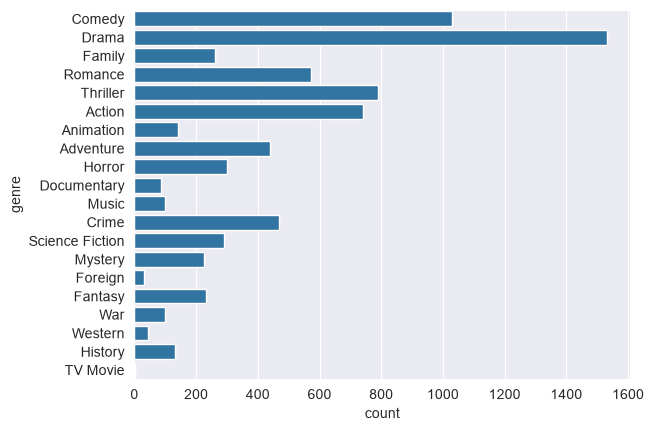

In [84]:
sns.barplot(x=genre_df['count'], y=genre_df['genre'])

In [85]:
genre_df.sort_values('count', ascending=False, inplace=True)

In [86]:
genre_df.max()

genre    Western
count       1531
dtype: object

In [87]:
genre_df.describe()

,count
count,20.00000
mean,375.55000
std,391.00067
min,1.00000
25%,100.00000
50%,246.00000
75%,494.50000
max,1531.00000


- Analysis of this 'describe'
- count means 20 unique genres
- the average of each genre appearance is 300+
- the std is close to mean which means that data is skewed
- also max value for one genre is 1500 and the other is 1 means that data is really skewed
- Conclusion: Data is really skewed due to std vs mean and min max comparison

For a normal distribution, we should have:

- mean ≈ median
- std noticeably smaller than mean
- min and max symmetrical around mean (e.g., min = 100, max = 400, mean = 250)
- 25% and 75% symmetrical around median (e.g., 25% = 200, median = 250, 75% = 300)

In [102]:
train['genre_names'] = train['genres'].apply(lambda x: retrieve_genres(x))
test['genre_names'] = test['genres'].apply(lambda x: retrieve_genres(x))

In [103]:
train['genre_names'].dtype

dtype('O')

In [104]:
type(train['genre_names'].iloc[0])

list

In [105]:
top_genres = genre_df.head(15)['genre'].tolist()

for genre in top_genres:
    train[f'genre_{genre}'] = train['genre_names'].apply(lambda x: 1 if genre in x else 0)
    test[f'genre_{genre}'] = test['genre_names'].apply(lambda x: 1 if genre in x else 0)

In [106]:
train.head()

,id,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_War
0,1,14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,0,0,0,0,0,0,0,0,0,0
1,2,40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,0,0,0,0,1,0,0,0,0,0
2,3,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,0,0,0,0,0,0,0,0,0,0
3,4,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,0,0,0,0,0,0,0,0,0,0
4,5,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,0,0,0,0,0,0,0,0,0,0


In [107]:
test.head()

,id,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_War
0,3001,0,"[{'id': 12, 'name': 'Adventure'}, {'id': 16, '...",http://www.pokemon.com/us/movies/movie-pokemon...,tt1226251,ja,ディアルガVSパルキアVSダークライ,Ash and friends (this time accompanied by newc...,3.851534,/tnftmLMemPLduW6MRyZE0ZUD19z.jpg,...,0,1,0,0,1,1,0,1,0,0
1,3002,88000,"[{'id': 27, 'name': 'Horror'}, {'id': 878, 'na...",NaN,tt0051380,en,Attack of the 50 Foot Woman,When an abused wife grows to giant size becaus...,3.559789,/9MgBNBqlH1sG4yG2u4XkwI5CoJa.jpg,...,0,0,1,1,0,0,0,0,0,0
2,3003,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,tt0118556,en,Addicted to Love,Good-natured astronomer Sam is devastated when...,8.085194,/ed6nD7h9sbojSWY2qrnDcSvDFko.jpg,...,0,0,0,0,0,0,0,0,0,0
3,3004,6800000,"[{'id': 18, 'name': 'Drama'}, {'id': 10752, 'n...",http://www.sonyclassics.com/incendies/,tt1255953,fr,Incendies,A mother's last wishes send twins Jeanne and S...,8.596012,/sEUG3qjxwHjxkzuO7plrRHhOZUH.jpg,...,0,0,0,0,0,0,1,0,0,1
4,3005,2000000,"[{'id': 36, 'name': 'History'}, {'id': 99, 'na...",NaN,tt0418753,en,Inside Deep Throat,"In 1972, a seemingly typical shoestring budget...",3.217680,/n4WC3zbelz6SG7rhkWbf8m9pMHB.jpg,...,0,0,0,0,0,0,0,0,1,0


In [109]:
train.drop(columns=['genres'], inplace=True)
test.drop(columns=['genres'], inplace=True)

In [110]:
train.head()

,id,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,...,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_War
0,1,14000000,NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...",...,0,0,0,0,0,0,0,0,0,0
1,2,40000000,NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]",...,0,0,0,0,1,0,0,0,0,0
2,3,3300000,http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...",...,0,0,0,0,0,0,0,0,0,0
3,4,1200000,http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,NaN,...,0,0,0,0,0,0,0,0,0,0
4,5,0,NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,NaN,...,0,0,0,0,0,0,0,0,0,0


In [111]:
for i, e in enumerate(train['production_companies'][:5]):
    print(i, e)

0 [{'name': 'Paramount Pictures', 'id': 4}, {'name': 'United Artists', 'id': 60}, {'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8411}]
1 [{'name': 'Walt Disney Pictures', 'id': 2}]
2 [{'name': 'Bold Films', 'id': 2266}, {'name': 'Blumhouse Productions', 'id': 3172}, {'name': 'Right of Way Films', 'id': 32157}]
3 nan
4 nan


In [112]:
@handle_na(default=0)
def number_of_companies(x):
    return len(x)

In [113]:
train['production_companies'].apply(lambda x: number_of_companies(x)).value_counts()

production_companies
0      156
41     109
38      86
42      68
51      50
      ... 
352      1
67       1
390      1
339      1
413      1
Name: count, Length: 361, dtype: int64

In [114]:
train['production_companies'].describe()

count                                          2844
unique                                         2383
top       [{'name': 'Paramount Pictures', 'id': 4}]
freq                                             51
Name: production_companies, dtype: object

In [118]:
train[train['production_companies'].apply(number_of_companies) > 11]

,id,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,...,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_War
0,1,14000000,NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...",...,0,0,0,0,0,0,0,0,0,0
1,2,40000000,NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]",...,0,0,0,0,1,0,0,0,0,0
2,3,3300000,http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...",...,0,0,0,0,0,0,0,0,0,0
6,7,14000000,http://www.thepossessionmovie.com/,tt0431021,en,The Possession,A young girl buys an antique box at a yard sal...,7.286477,/4QjzFuaZmB4btGnLwAgdp23BzIU.jpg,"[{'name': 'Ghost House Pictures', 'id': 768}, ...",...,0,0,1,0,0,0,0,0,0,0
8,9,0,NaN,tt0117110,en,Muppet Treasure Island,After telling the story of Flint's last journe...,6.902423,/5A8gKzOrF9Z7tSUX6xd5dEx4NXf.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}, {'...",...,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,0,NaN,tt0109403,en,Chasers,Military men Rock Reilly and Eddie Devane are ...,9.853270,/j8Q7pQ27hvH54wpxJzIuQgQCdro.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...",...,0,0,0,0,0,0,0,0,0,0
2996,2997,0,NaN,tt2364975,sv,Vi är bäst!,Three girls in 1980s Stockholm decide to form ...,3.727996,/sS01LSy6KDrCZAhtkO18UdnWFT1.jpg,"[{'name': 'Memfis Film', 'id': 321}, {'name': ...",...,0,0,0,0,0,0,0,0,0,0
2997,2998,65000000,NaN,tt0116908,en,The Long Kiss Goodnight,"Samantha Caine, suburban homemaker, is the ide...",14.482345,/4MENR8x6mYqnZvp2hGjSaPJz64J.jpg,"[{'name': 'New Line Cinema', 'id': 12}, {'name...",...,1,0,0,0,0,0,1,0,0,0
2998,2999,42000000,http://www.alongcamepolly.com/,tt0343135,en,Along Came Polly,Reuben Feffer is a guy who's spent his entire ...,15.725542,/nIY4kvJTTnxoBR0wycrXng5MOYs.jpg,"[{'name': 'Jersey Films', 'id': 216}, {'name':...",...,0,0,0,0,0,0,0,0,0,0


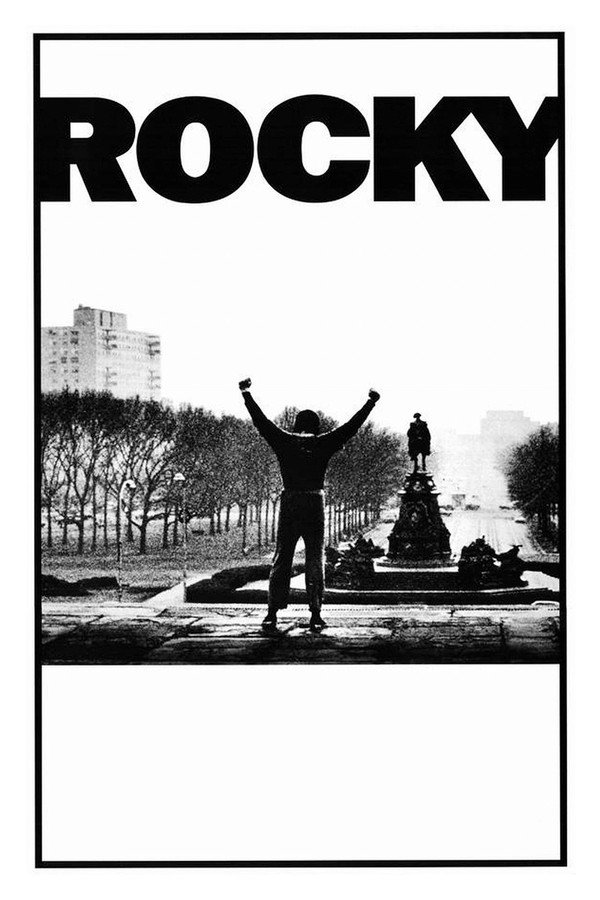

In [122]:
from urllib.request import urlopen
from PIL import Image

img = Image.open(urlopen("https://image.tmdb.org/t/p/w600_and_h900_bestv2/i5xiwdSsrecBvO7mIfAJixeEDSg.jpg"))
img

In [124]:
@handle_na(default=[])
def retrieve_company_names(x):
    x = ast.literal_eval(x)
    return [i['name'] for i in x]

In [125]:
list_of_companies = list(train['production_companies'].apply(lambda x: retrieve_company_names(x)))

In [126]:
Counter([i for j in list_of_companies for i in j]).most_common(30)

[('Warner Bros.', 202),
 ('Universal Pictures', 188),
 ('Paramount Pictures', 161),
 ('Twentieth Century Fox Film Corporation', 138),
 ('Columbia Pictures', 91),
 ('Metro-Goldwyn-Mayer (MGM)', 84),
 ('New Line Cinema', 75),
 ('Touchstone Pictures', 63),
 ('Walt Disney Pictures', 62),
 ('Columbia Pictures Corporation', 61),
 ('TriStar Pictures', 53),
 ('Relativity Media', 48),
 ('Canal+', 46),
 ('United Artists', 44),
 ('Miramax Films', 40),
 ('Village Roadshow Pictures', 36),
 ('Regency Enterprises', 31),
 ('BBC Films', 30),
 ('Dune Entertainment', 30),
 ('Working Title Films', 30),
 ('Fox Searchlight Pictures', 29),
 ('StudioCanal', 28),
 ('Lionsgate', 28),
 ('DreamWorks SKG', 27),
 ('Fox 2000 Pictures', 25),
 ('Summit Entertainment', 24),
 ('Hollywood Pictures', 24),
 ('Orion Pictures', 24),
 ('Amblin Entertainment', 23),
 ('Dimension Films', 23)]

In [130]:
train['company_names'] = train['production_companies'].apply(retrieve_company_names)
train['num_companies'] = train['company_names'].apply(len)

top_companies = [m[0] for m in Counter([c for sublist in train['company_names'] for c in sublist]).most_common(30)]

for g in top_companies:
    train[f'production_company_{g}'] = train['company_names'].apply(lambda x: 1 if g in x else 0)

test['company_names'] = test['production_companies'].apply(retrieve_company_names)
test['num_companies'] = test['company_names'].apply(len)
for g in top_companies:
    test[f'production_company_{g}'] = test['company_names'].apply(lambda x: 1 if g in x else 0)

train = train.drop(['production_companies', 'company_names'], axis=1)
test = test.drop(['production_companies', 'company_names'], axis=1)

In [131]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 69 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   id                                                         3000 non-null   int64  
 1   budget                                                     3000 non-null   int64  
 2   homepage                                                   946 non-null    str    
 3   imdb_id                                                    3000 non-null   str    
 4   original_language                                          3000 non-null   str    
 5   original_title                                             3000 non-null   str    
 6   overview                                                   2992 non-null   str    
 7   popularity                                                 3000 non-null   float64
 8   poster_path        

In [132]:
train.head()

,id,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_countries,...,production_company_Fox Searchlight Pictures,production_company_StudioCanal,production_company_Lionsgate,production_company_DreamWorks SKG,production_company_Fox 2000 Pictures,production_company_Summit Entertainment,production_company_Hollywood Pictures,production_company_Orion Pictures,production_company_Amblin Entertainment,production_company_Dimension Films
0,1,14000000,NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'iso_3166_1': 'US', 'name': 'United States o...",...,0,0,0,0,0,0,0,0,0,0
1,2,40000000,NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,"[{'iso_3166_1': 'US', 'name': 'United States o...",...,0,0,0,0,0,0,0,0,0,0
2,3,3300000,http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,"[{'iso_3166_1': 'US', 'name': 'United States o...",...,0,0,0,0,0,0,0,0,0,0
3,4,1200000,http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,"[{'iso_3166_1': 'IN', 'name': 'India'}]",...,0,0,0,0,0,0,0,0,0,0
4,5,0,NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",...,0,0,0,0,0,0,0,0,0,0


In [133]:
for i, e in enumerate(train['production_countries']):
    print(f"{i} - {e}")

0 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
1 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
2 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
3 - [{'iso_3166_1': 'IN', 'name': 'India'}]
4 - [{'iso_3166_1': 'KR', 'name': 'South Korea'}]
5 - nan
6 - [{'iso_3166_1': 'US', 'name': 'United States of America'}, {'iso_3166_1': 'CA', 'name': 'Canada'}]
7 - nan
8 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
9 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
10 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
11 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
12 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
13 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
14 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
15 - [{'iso_3166_1': 'RS', 'name': 'Serbia'}]
16 - [{'iso_3166_1': 'US', 'name': 'United States of America'}]
17 - [{'iso_3166_1': 'GB', 'name': 'United

In [139]:
@handle_na(default=[])
def retrieve_country_names(x):
    x = ast.literal_eval(x)
    return [i['name'] for i in x]

In [142]:
train['country_names'] = list(train['production_countries'].apply(retrieve_country_names))
train['num_countries'] = train['country_names'].apply(len)

all_countries_flat = [c for sublist in train['country_names'] for c in sublist]
top_countries = [m[0] for m in Counter(all_countries_flat).most_common(25)]

for g in top_countries:
    train[f'production_country_{g}'] = train['country_names'].apply(lambda x: 1 if g in x else 0)

test['country_names'] = test['production_countries'].apply(retrieve_country_names)
test['num_countries'] = test['country_names'].apply(len)
for g in top_countries:
    test[f'production_country_{g}'] = test['country_names'].apply(lambda x: 1 if g in x else 0)

train = train.drop(['production_countries', 'country_names'], axis=1)
test = test.drop(['production_countries', 'country_names'], axis=1)

In [144]:
type(train['spoken_languages'].dropna().iloc[0])

str

In [145]:
train['spoken_languages'].dropna().iloc[0]

"[{'iso_639_1': 'en', 'name': 'English'}]"

In [146]:
@handle_na(default=[])
def retrieve_spoken_languages(x):
    x = ast.literal_eval(x)
    return [i['name'] for i in x]

In [148]:
train['language_names'] = train['spoken_languages'].apply(retrieve_spoken_languages)
train['num_languages'] = train['language_names'].apply(len)

In [149]:
all_languages_flat = [l for sublist in train['language_names'] for l in sublist]
top_languages = [m[0] for m in Counter(all_languages_flat).most_common(15)]

In [150]:
for lang in top_languages:
    train[f'language_{lang}'] = train['language_names'].apply(lambda x: 1 if lang in x else 0)

In [153]:
test['language_names'] = test['spoken_languages'].apply(retrieve_spoken_languages)
test['num_languages'] = test['language_names'].apply(len)
for lang in top_languages:
    test[f'language_{lang}'] = test['language_names'].apply(lambda x: 1 if lang in x else 0)

In [154]:
train = train.drop(['spoken_languages', 'language_names'], axis=1)
test = test.drop(['spoken_languages', 'language_names'], axis=1)